In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve, roc_curve, f1_score, precision_score, recall_score,
    make_scorer, mean_absolute_error, mean_squared_error
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from joblib import Memory

Shape: (11554, 14)
Columns: ['year', 'month', 'dom', 'hour', 'rf_', 'RH1000', 'RH925', 'RH850', 'RH700', 'RH500', 'RH400', 'RH300', 'RH250', 'RH150']
Head:
   year  month  dom  hour  rf_  RH1000  RH925  RH850  RH700  RH500  RH400  \
0  2005      1    1     8  0.0    27.7   44.0    7.0   47.1   14.8   13.9   
1  2005      1    1    20  0.0    23.0   27.5    3.4   73.8    9.0    3.7   
2  2005      1    2     8  0.0    31.6   60.4    5.8   70.1    6.6    2.0   
3  2005      1    2    20  0.0    40.3   70.5   78.2   64.4   11.7   14.5   
4  2005      1    3     8  0.0    62.4   49.9   90.8   23.6    3.2    3.6   

   RH300    RH250    RH150  
0    6.1 -99999.0 -99999.0  
1    5.8      4.4      4.9  
2    4.1      6.6      4.1  
3    6.7     11.2      4.8  
4   10.5      4.6      6.6  
Dtypes:
year        int64
month       int64
dom         int64
hour        int64
rf_       float64
RH1000    float64
RH925     float64
RH850     float64
RH700     float64
RH500     float64
RH400     float64
R

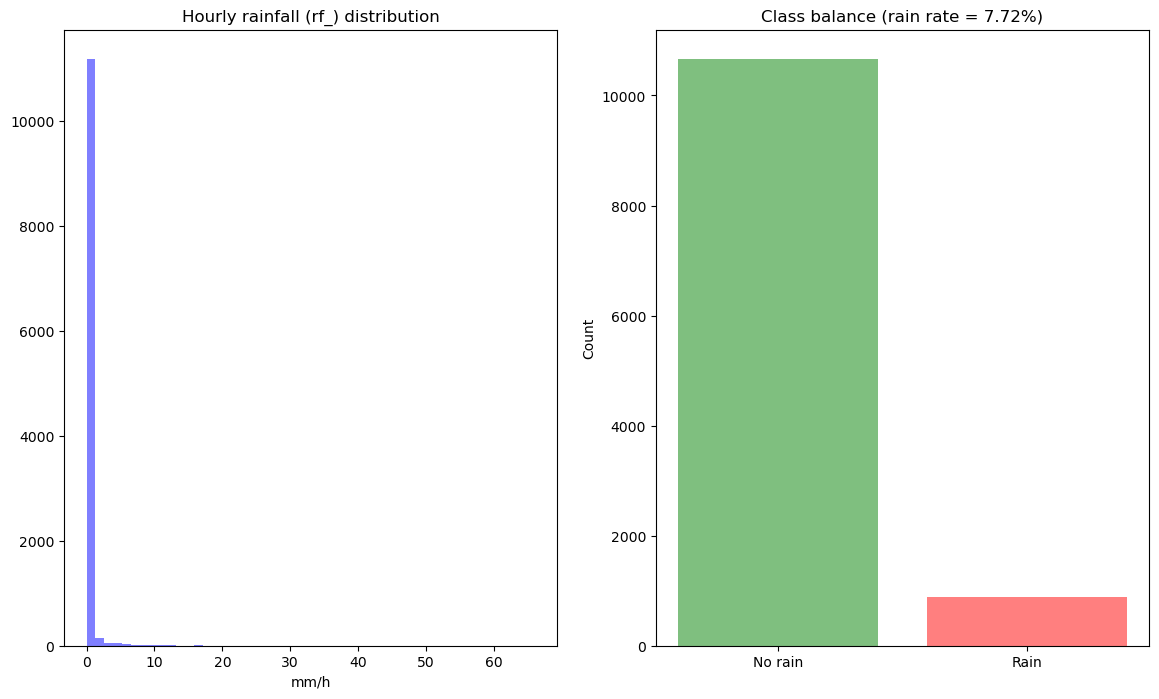

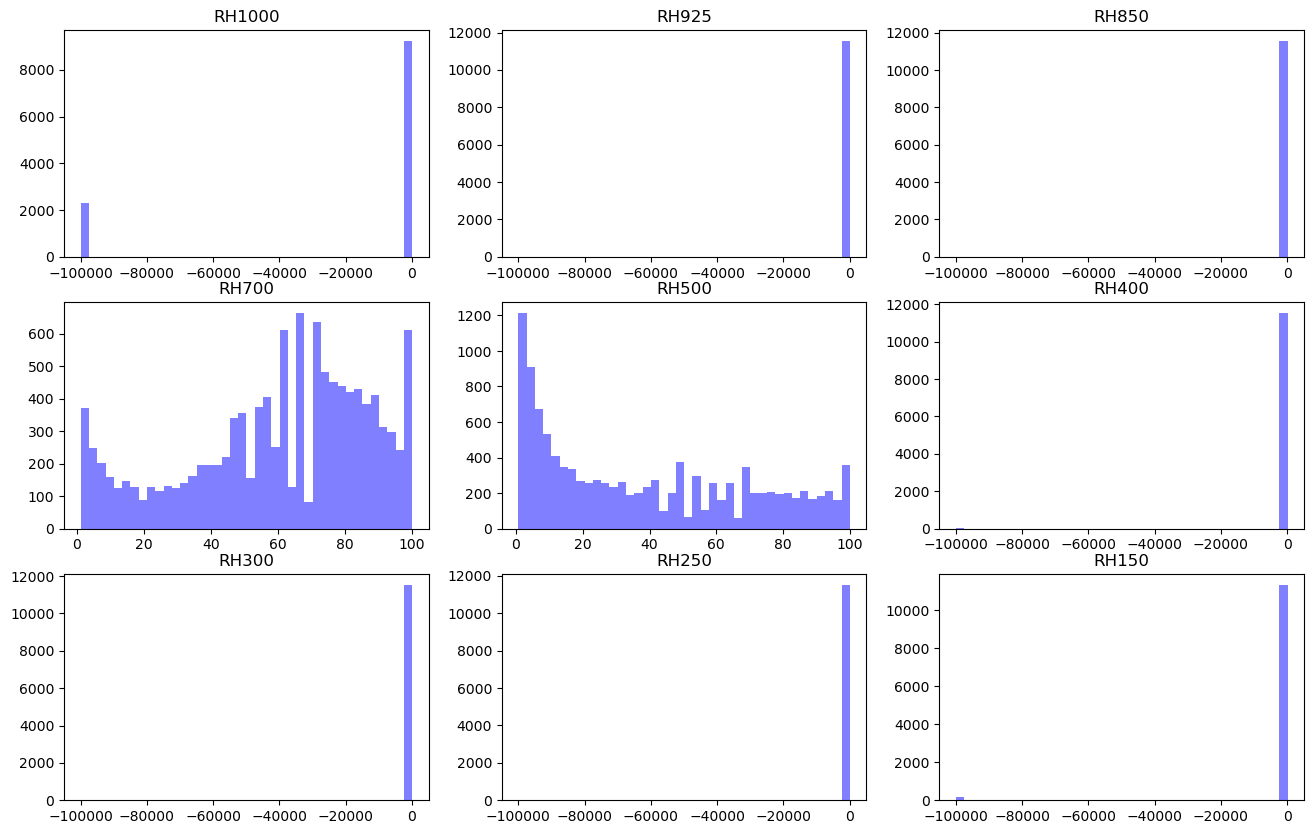

In [2]:
df = pd.read_csv('RadiosondeRH_Rainfall.csv')
print('Shape:', df.shape)
print('Columns:', list(df.columns))
print('Head:')
print(df.head())
print('Dtypes:')
print(df.dtypes)

rh_cols = [c for c in df.columns if c.startswith('RH')]

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].hist(df['rf_'], bins=50, color='blue', alpha=0.5)
axes[0].set_title('Hourly rainfall (rf_) distribution')
axes[0].set_xlabel('mm/h')

rain_rate = (df['rf_'] > 0).mean()
axes[1].bar(['No rain','Rain'], [ (df['rf_']==0).sum(), (df['rf_']>0).sum() ], color=['green','red'], alpha=0.5)
axes[1].set_title(f'Class balance (rain rate = {rain_rate*100:.2f}%)')
axes[1].set_ylabel('Count')
plt.show()

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
for ax, col in zip(axes.ravel(), rh_cols):
    ax.hist(df[col], bins=40, color='blue', alpha=0.5)
    ax.set_title(col)
plt.show()

Missing data per RH level (after cleaning to NaN, before impute):
RH1000    0.200710
RH150     0.016531
RH250     0.002250
RH925     0.000952
RH300     0.000779
RH400     0.000260
RH850     0.000173
RH700     0.000000
RH500     0.000000
dtype: float64
Split sizes — Train: 6932 Val: 2311 Test: 2311


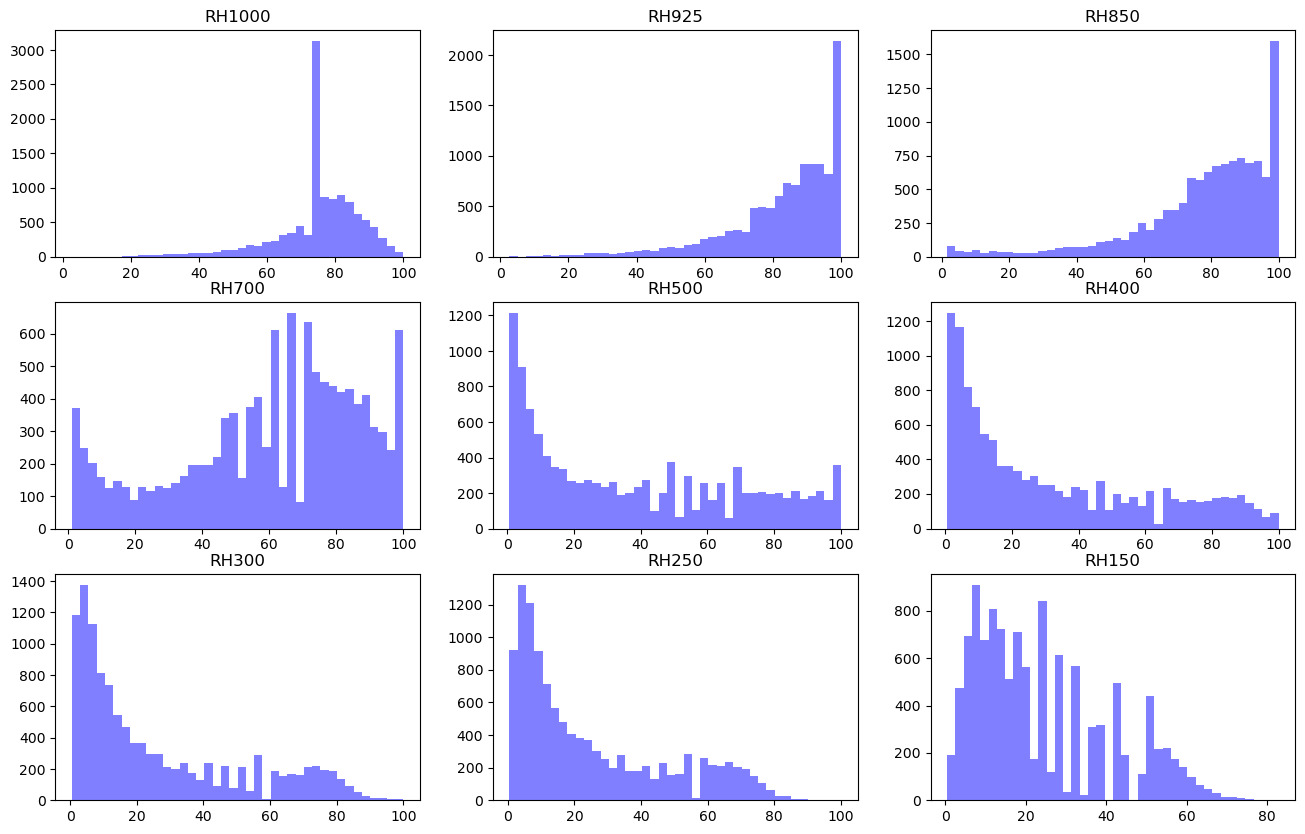

In [3]:
# convert -99999 to NaN
if len(rh_cols) == 0:
    rh_cols = [c for c in df.columns if c.startswith('RH')]

df[rh_cols] = df[rh_cols].replace(-99999, np.nan)

# targets
df['rain_flag'] = (df['rf_'] > 0).astype(int)

miss = df[rh_cols].isna().mean().sort_values(ascending=False)
print('Missing data per RH level (after cleaning to NaN, before impute):')
print(miss)

# compute column means (NaNs ignored)
global_means = df[rh_cols].mean()
# If any column is entirely NaN, its mean will be NaN; drop such columns from rh_cols
all_nan_cols = list(global_means[global_means.isna()].index)
if len(all_nan_cols) > 0:
    print('Dropping RH columns with all values missing (mean is NaN):', all_nan_cols)
    rh_cols = [c for c in rh_cols if c not in all_nan_cols]
    global_means = df[rh_cols].mean()

# fill NaNs with means
df[rh_cols] = df[rh_cols].fillna(global_means)

# 60/20/20 split, stratified by rain_flag
idx_all = np.arange(len(df))
train_i, temp_i = train_test_split(
    idx_all,
    test_size=0.4,
    random_state=42,
    stratify=df['rain_flag']
)
val_i, test_i = train_test_split(
    temp_i,
    test_size=0.5,
    random_state=42,
    stratify=df.loc[temp_i, 'rain_flag']
)

train_idx = np.zeros(len(df), dtype=bool); train_idx[train_i] = True
val_idx   = np.zeros(len(df), dtype=bool); val_idx[val_i]   = True
test_idx  = np.zeros(len(df), dtype=bool); test_idx[test_i] = True

print('Split sizes — Train:', train_idx.sum(), 'Val:', val_idx.sum(), 'Test:', test_idx.sum())

fig, axes = plt.subplots(3, 3, figsize=(16,10))
for ax, col in zip(axes.ravel(), rh_cols[:9]):
    ax.hist(df[col], bins=40, color='blue', alpha=0.5)
    ax.set_title(col)
plt.show()

Replace NaN with column mean, stratify the splits since we have very imbalanced data

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Fitting 3 folds for each of 30 candidates, totalling 90 fits


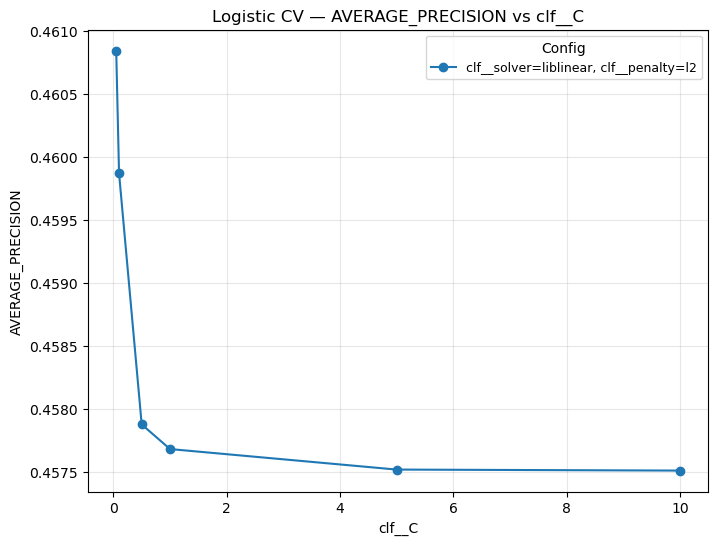

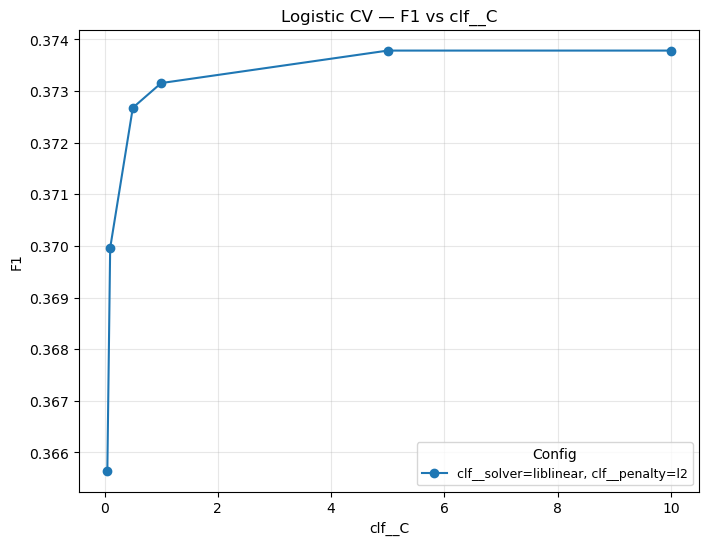

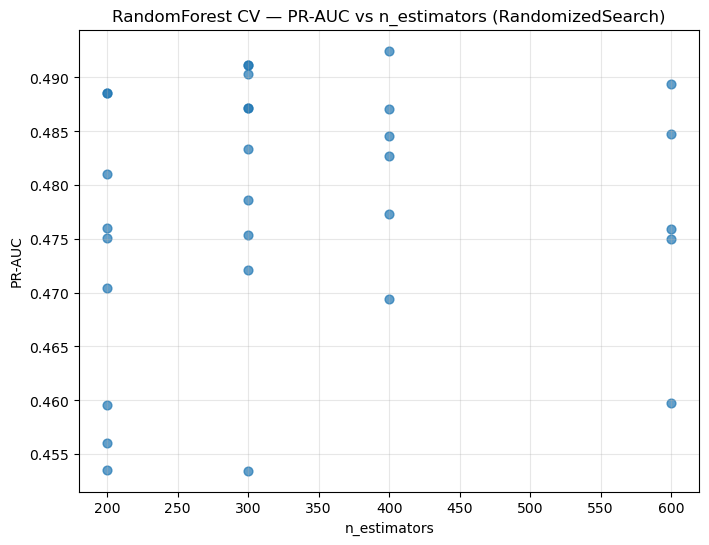

In [4]:
# train/val/test matrices
X_train = df.loc[train_idx, rh_cols]
y_train = df.loc[train_idx, 'rain_flag']
X_val   = df.loc[val_idx,   rh_cols]
y_val   = df.loc[val_idx,   'rain_flag']
X_test  = df.loc[test_idx,  rh_cols]
y_test  = df.loc[test_idx,  'rain_flag']

mem = Memory(location='pipeline_cache', verbose=0)
mean_imputer = SimpleImputer(strategy='mean')

logit_pipe = Pipeline([
    ('imputer', mean_imputer),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
], memory=mem)

rf_cls_pipe = Pipeline([
    ('imputer', mean_imputer),
    ('clf', RandomForestClassifier(
        random_state=42, class_weight='balanced', max_samples=0.8
    ))
], memory=mem)

# hyperparameters
logit_param_grid = {
    'clf__C': [0.05, 0.1, 0.5, 1, 5, 10],
    'clf__penalty': ['l2'],
    'clf__solver': ['liblinear'],
}

rf_param_dist = {
    'clf__n_estimators': [200, 300, 400, 600],
    'clf__max_depth': [None, 10, 16, 24, 32],
    'clf__min_samples_leaf': [1, 2, 4],
    'clf__max_features': ['sqrt', 'log2', None],
}

# CV & metrics
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring = {
    'roc_auc': 'roc_auc',
    'average_precision': 'average_precision',
    'f1': make_scorer(f1_score, pos_label=1)
}

logit_gs = GridSearchCV(
    estimator=logit_pipe, param_grid=logit_param_grid, scoring=scoring,
    refit='average_precision', cv=cv, n_jobs=-1, return_train_score=True, verbose=1
)
logit_gs.fit(X_train, y_train)

rf_rs = RandomizedSearchCV(
    estimator=rf_cls_pipe, param_distributions=rf_param_dist, n_iter=30, scoring=scoring,
    refit='average_precision', cv=cv, n_jobs=-1, random_state=42, return_train_score=True, verbose=1
)
rf_rs.fit(X_train, y_train)

def plot_cv_results(cv_df, model_name, x_param, group_params=None, metric='mean_test_average_precision'):
    cols = ['param_' + x_param, metric]
    if group_params:
        cols += ['param_' + gp for gp in group_params]
    df_plot = cv_df[cols].copy().sort_values('param_' + x_param)
    plt.figure(figsize=(8, 6))
    if group_params:
        groups = df_plot.groupby(['param_' + gp for gp in group_params])
        for grp_vals, g in groups:
            label = ', '.join(f"{gp}={v}" for gp, v in zip(group_params, grp_vals))
            plt.plot(g['param_' + x_param], g[metric], marker='o', label=label)
        plt.legend(title='Config', fontsize=9)
    else:
        plt.plot(df_plot['param_' + x_param], df_plot[metric], marker='o')
    plt.xlabel(x_param)
    plt.ylabel(metric.replace('mean_test_', '').upper())
    plt.title(f"{model_name} CV — {metric.replace('mean_test_', '').upper()} vs {x_param}")
    plt.grid(alpha=0.3)
    plt.show()

logit_cv = pd.DataFrame(logit_gs.cv_results_)
plot_cv_results(logit_cv, "Logistic", x_param='clf__C', group_params=['clf__solver', 'clf__penalty'], metric='mean_test_average_precision')
plot_cv_results(logit_cv, "Logistic", x_param='clf__C', group_params=['clf__solver', 'clf__penalty'], metric='mean_test_f1')

rf_cv = pd.DataFrame(rf_rs.cv_results_)
plt.figure(figsize=(8,6))
plt.scatter(rf_cv['param_clf__n_estimators'], rf_cv['mean_test_average_precision'], s=40, alpha=0.7)
plt.xlabel('n_estimators'); plt.ylabel('PR-AUC')
plt.title('RandomForest CV — PR-AUC vs n_estimators (RandomizedSearch)')
plt.grid(alpha=0.3)
plt.show()

Use PR‑AUC as our main metrics since we have rare positive results

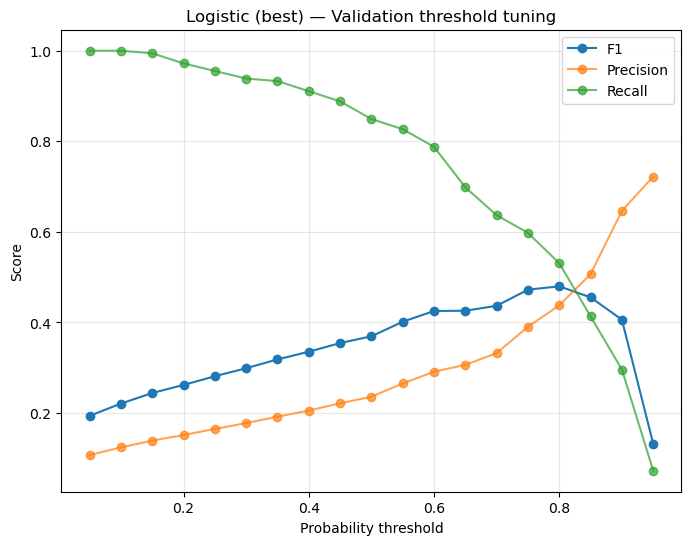

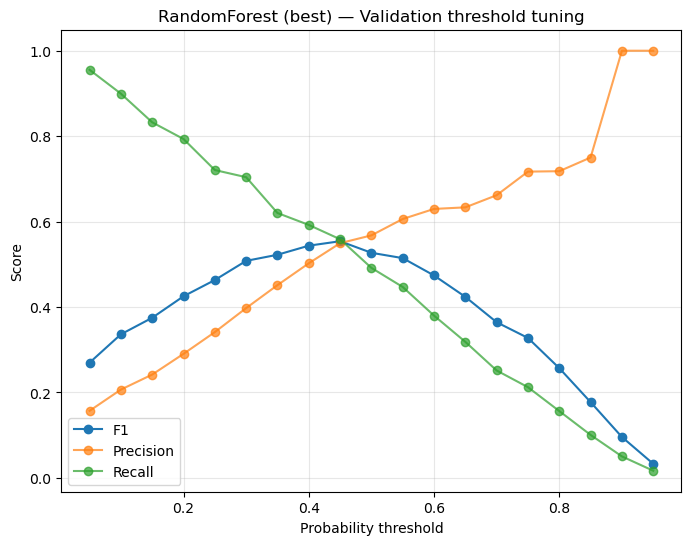

Chosen validation thresholds — Logistic: 0.7999999999999999, RandomForest: 0.44999999999999996
Validation F1 — Logistic: 0.4797979797979798 (P=0.4377880184331797, R=0.5307262569832403)
Validation F1 — RandomForest: 0.554016620498615 (P=0.5494505494505495, R=0.5586592178770949)


In [5]:
# choose best models (by PR-AUC), then tune threshold (F1 on validation)
best_logit = logit_gs.best_estimator_
best_rf = rf_rs.best_estimator_

def tune_threshold(estimator, X_val, y_val, model_name):
    proba_val = estimator.predict_proba(X_val)[:, 1]
    thresholds = np.linspace(0.05, 0.95, 19)
    f1s, precs, recs = [], [], []
    for t in thresholds:
        preds_t = (proba_val >= t).astype(int)
        f1s.append(f1_score(y_val, preds_t))
        precs.append(precision_score(y_val, preds_t, zero_division=0))
        recs.append(recall_score(y_val, preds_t))
    plt.figure(figsize=(8,6))
    plt.plot(thresholds, f1s, marker='o', label='F1')
    plt.plot(thresholds, precs, marker='o', label='Precision', alpha=0.7)
    plt.plot(thresholds, recs, marker='o', label='Recall', alpha=0.7)
    plt.xlabel('Probability threshold'); plt.ylabel('Score')
    plt.title(f'{model_name} — Validation threshold tuning')
    plt.grid(alpha=0.3); plt.legend(); plt.show()
    best_idx = int(np.argmax(f1s))
    return thresholds[best_idx], f1s[best_idx], precs[best_idx], recs[best_idx]

thr_logit, f1_logit_val, p_logit_val, r_logit_val = tune_threshold(best_logit, X_val, y_val, 'Logistic (best)')
thr_rf,    f1_rf_val,    p_rf_val,    r_rf_val    = tune_threshold(best_rf,    X_val, y_val, 'RandomForest (best)')

print(f"Chosen validation thresholds — Logistic: {thr_logit}, RandomForest: {thr_rf}")
print(f"Validation F1 — Logistic: {f1_logit_val} (P={p_logit_val}, R={r_logit_val})")
print(f"Validation F1 — RandomForest: {f1_rf_val} (P={p_rf_val}, R={r_rf_val})")

RandomForest outperforms Logistic in validation

Logistic (tuned) — Test ROC-AUC=0.8991081822826952, PR-AUC=0.46709070710282896, F1=0.5012531328320802, thr=0.7999999999999999
RandomForest (tuned) — Test ROC-AUC=0.9044654097989329, PR-AUC=0.5175810011154147, F1=0.5511811023622047, thr=0.44999999999999996


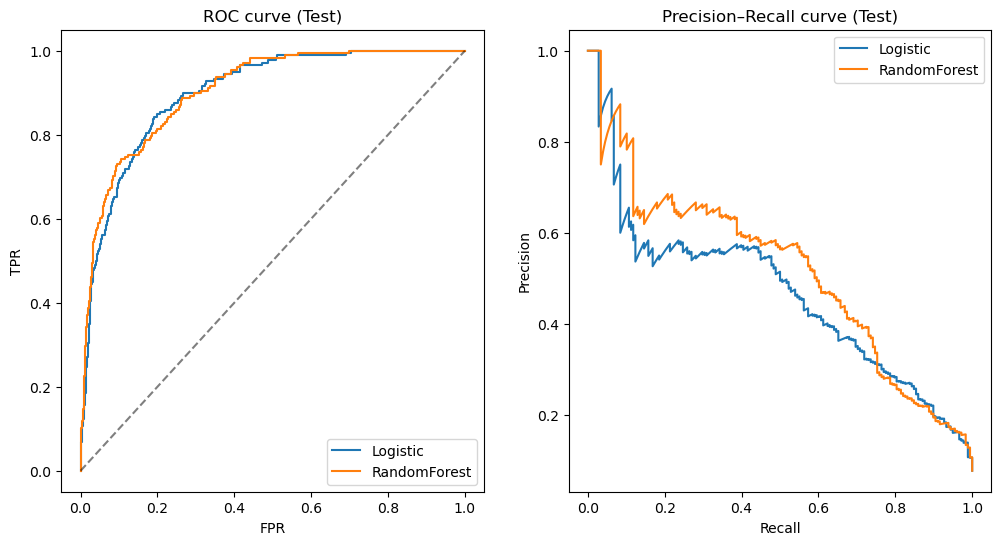

In [6]:
# test evaluation
def evaluate_on_test(estimator, X_test, y_test, thr, name):
    proba = estimator.predict_proba(X_test)[:, 1]
    preds = (proba >= thr).astype(int)
    roc = roc_auc_score(y_test, proba)
    pr  = average_precision_score(y_test, proba)
    f1  = f1_score(y_test, preds)
    cm  = confusion_matrix(y_test, preds)
    print(f"{name} — Test ROC-AUC={roc}, PR-AUC={pr}, F1={f1}, thr={thr}")
    return {'ROC_AUC': roc, 'PR_AUC': pr, 'F1': f1, 'CM': cm, 'proba': proba, 'preds': preds}

metrics_tuned = {}
metrics_tuned['Logistic']     = evaluate_on_test(best_logit, X_test, y_test, thr_logit, 'Logistic (tuned)')
metrics_tuned['RandomForest'] = evaluate_on_test(best_rf,    X_test, y_test, thr_rf,    'RandomForest (tuned)')

# ROC & PR curves for tuned models on TEST
fig, ax = plt.subplots(1,2, figsize=(12,6))
for name in ['Logistic', 'RandomForest']:
    fpr, tpr, _ = roc_curve(y_test, metrics_tuned[name]['proba'])
    ax[0].plot(fpr, tpr, label=name)
    prec, rec, _ = precision_recall_curve(y_test, metrics_tuned[name]['proba'])
    ax[1].plot(rec, prec, label=name)
ax[0].plot([0,1],[0,1],'k--',alpha=0.5)
ax[0].set_title('ROC curve (Test)')
ax[0].set_xlabel('FPR')
ax[0].set_ylabel('TPR')
ax[1].set_title('Precision–Recall curve (Test)')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[0].legend()
ax[1].legend()
plt.show()

RF is consistently stronger (higher PR‑AUC and F1), both models show high ROC‑AUC, but in imbalanced problems, PR‑AUC is more informative

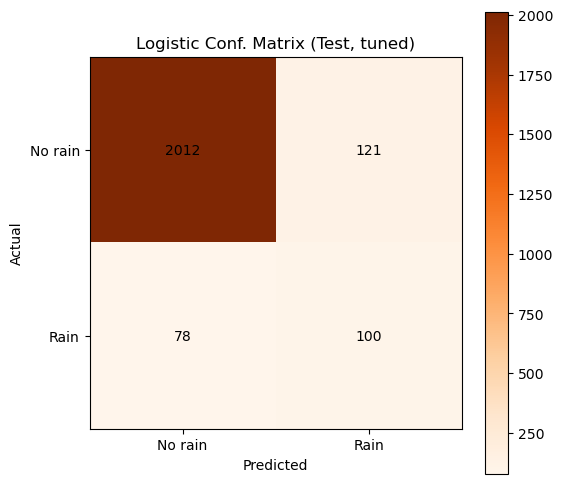

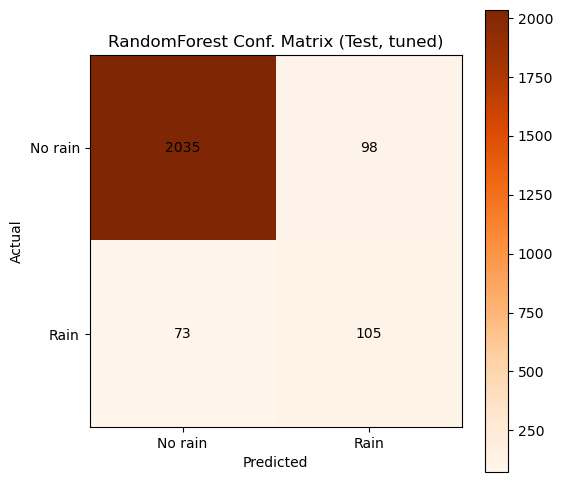

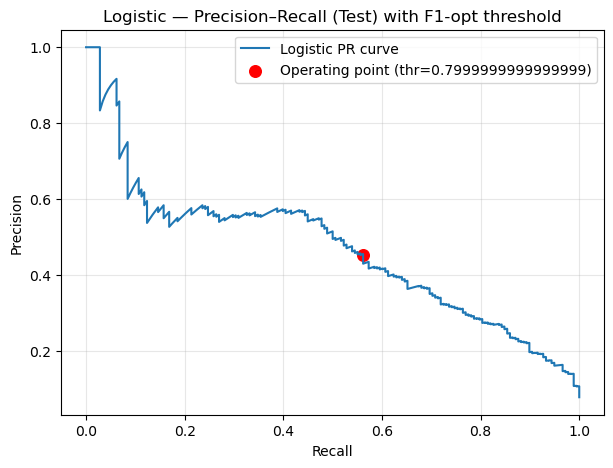

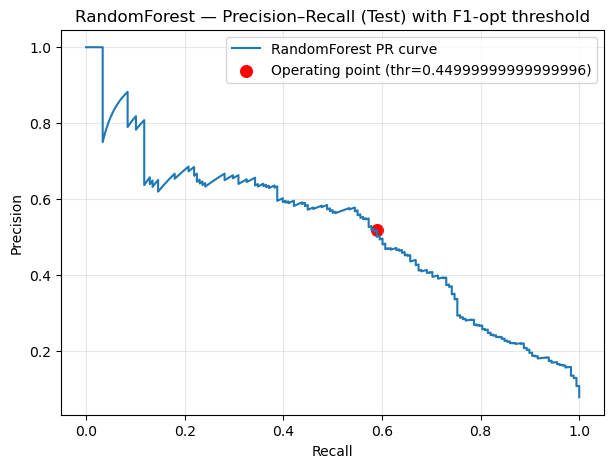

Logistic — final TEST evaluation
 Threshold (F1-opt on validation): 0.7999999999999999
 Best hyperparameters: {'C': 0.05, 'penalty': 'l2', 'solver': 'liblinear'}
 Metrics (TEST): ROC-AUC=0.8991081822826952, PR-AUC=0.46709070710282896, F1=0.5012531328320802
RandomForest — final TEST evaluation
 Threshold (F1-opt on validation): 0.44999999999999996
 Best hyperparameters: {'n_estimators': 400, 'max_depth': 24, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_samples': 0.8}
 Metrics (TEST): ROC-AUC=0.9044654097989329, PR-AUC=0.5175810011154147, F1=0.5511811023622047


In [7]:
def plot_confusion_matrix(cm, class_names=('No rain','Rain'), title='Confusion Matrix'):
    fig, ax = plt.subplots(figsize=(6,6))
    im = ax.imshow(cm, cmap='Oranges')
    ax.set_xticks([0,1]); ax.set_xticklabels(class_names)
    ax.set_yticks([0,1]); ax.set_yticklabels(class_names)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
    fig.colorbar(im, ax=ax)
    plt.show()

for name in ['Logistic', 'RandomForest']:
    plot_confusion_matrix(metrics_tuned[name]['CM'], title=f'{name} Conf. Matrix (Test, tuned)')

for name in ['Logistic', 'RandomForest']:
    proba = metrics_tuned[name]['proba']
    thr = thr_logit if name == 'Logistic' else thr_rf
    prec, rec, _ = precision_recall_curve(y_test, proba)
    preds = (proba >= thr).astype(int)
    p_op = precision_score(y_test, preds, zero_division=0)
    r_op = recall_score(y_test, preds)
    plt.figure(figsize=(7,5))
    plt.plot(rec, prec, label=f'{name} PR curve')
    plt.scatter(r_op, p_op, s=70, color='red', label=f'Operating point (thr={thr})')
    plt.title(f'{name} — Precision–Recall (Test) with F1-opt threshold')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

best_params = {
    'Logistic': {
        'C': logit_gs.best_params_.get('clf__C'),
        'penalty': logit_gs.best_params_.get('clf__penalty'),
        'solver': logit_gs.best_params_.get('clf__solver'),
    },
    'RandomForest': {
        'n_estimators': rf_rs.best_params_.get('clf__n_estimators'),
        'max_depth': rf_rs.best_params_.get('clf__max_depth'),
        'min_samples_leaf': rf_rs.best_params_.get('clf__min_samples_leaf'),
        'max_features': rf_rs.best_params_.get('clf__max_features'),
        'max_samples': rf_rs.best_estimator_.named_steps['clf'].max_samples
    }
}

for name in ['Logistic', 'RandomForest']:
    thr = thr_logit if name == 'Logistic' else thr_rf
    m = metrics_tuned[name]
    bp = best_params[name]
    print(f"{name} — final TEST evaluation")
    print(f" Threshold (F1-opt on validation): {thr}")
    print(f" Best hyperparameters: {bp}")
    print(f" Metrics (TEST): ROC-AUC={m['ROC_AUC']}, PR-AUC={m['PR_AUC']}, F1={m['F1']}")

The printed F1 again favors RF (0.551), confirming earlier findings, also notice that we have many TN results (again, because of rare rainfall)

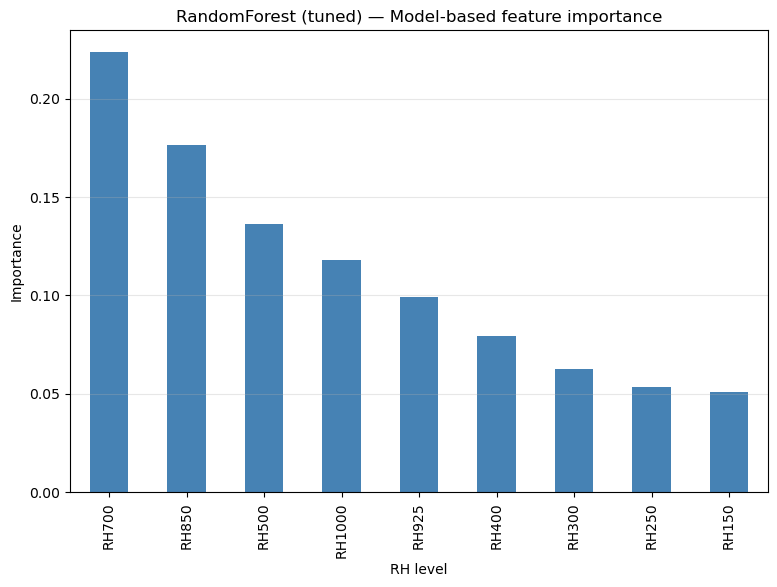

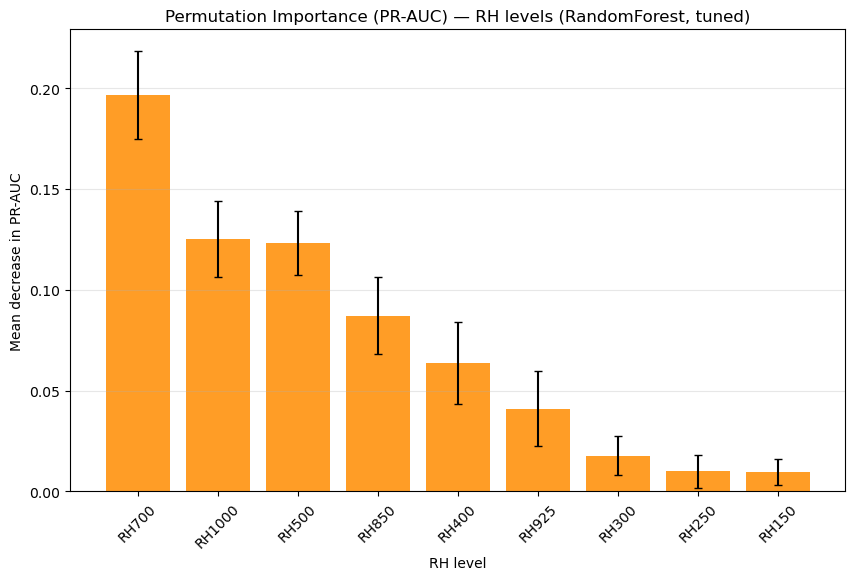

Top RH levels by PR-AUC permutation importance:
        perm_imp_mean  perm_imp_std
RH700        0.196398      0.021795
RH1000       0.125178      0.018877
RH500        0.123167      0.015999
RH850        0.087266      0.018962
RH400        0.063759      0.020507


In [8]:
# RandomForest tuned feature importance
rf_tuned = best_rf
rf_clf = rf_tuned.named_steps['clf']
fi = pd.Series(rf_clf.feature_importances_, index=rh_cols).sort_values(ascending=False)
plt.figure(figsize=(9,6))
fi.plot(kind='bar', color='steelblue')
plt.title('RandomForest (tuned) — Model-based feature importance')
plt.ylabel('Importance')
plt.xlabel('RH level')
plt.grid(axis='y', alpha=0.3)
plt.show()


# permutation importance (PR-AUC)
perm = permutation_importance(
    rf_tuned, X_test, y_test, n_repeats=20, random_state=42, scoring='average_precision'
)
imp_mean = pd.Series(perm.importances_mean, index=rh_cols)
imp_std  = pd.Series(perm.importances_std,  index=rh_cols)
imp_sorted = imp_mean.sort_values(ascending=False)
plt.figure(figsize=(10,6))
plt.bar(imp_sorted.index,
        imp_sorted.values,
        yerr=imp_std[imp_sorted.index].values,
        color='darkorange', alpha=0.85, capsize=3)
plt.title('Permutation Importance (PR-AUC) — RH levels (RandomForest, tuned)')
plt.ylabel('Mean decrease in PR-AUC'); plt.xlabel('RH level')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

# permutation importance
top = pd.DataFrame({
    'perm_imp_mean': imp_sorted.head(),
    'perm_imp_std': imp_std[imp_sorted.head().index]
})
print("Top RH levels by PR-AUC permutation importance:")
print(top)

RH700 dominates the model’s reliance in terms of PR‑AUC, near‑surface RH1000 also ranks high

In [9]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def neg_rmse_scorer(estimator, X, y):
    y_hat = estimator.predict(X)
    return -np.sqrt(mean_squared_error(y, y_hat))

# rain only subsets
rain_train_mask = df['rf_'] > 0
rain_test_mask  = df['rf_'] > 0

X_train_reg = df.loc[train_idx & rain_train_mask, rh_cols]
y_train_reg = df.loc[train_idx & rain_train_mask, 'rf_']
X_test_reg  = df.loc[test_idx  & rain_test_mask,  rh_cols]
y_test_reg  = df.loc[test_idx  & rain_test_mask,  'rf_']
print(f"Rain-only sizes — Train: {len(y_train_reg)}Test: {len(y_test_reg)}")

# pipelines and caching
mem = Memory(location='pipeline_cache_reg', verbose=0)
# Imputer kept for parity, but does nothing (data already imputed with global means)
imputer = SimpleImputer(strategy='mean')

rf_reg_pipe = Pipeline([
    ('imputer', imputer),
    ('reg', RandomForestRegressor(random_state=42))
], memory=mem)

gb_reg_pipe = Pipeline([
    ('imputer', imputer),
    ('reg', GradientBoostingRegressor(random_state=42))
], memory=mem)

cv = 3

# RandomForestRegressor
rf_param_dist = {
    'reg__n_estimators': [200, 300, 400, 600],
    'reg__max_depth': [None, 4, 6, 8, 12],
    'reg__min_samples_leaf': [1, 2, 4],
    'reg__max_features': ['sqrt', 'log2', 0.7, 1.0],
}

rf_rs = RandomizedSearchCV(
    estimator=rf_reg_pipe,
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring={
        'neg_mae': 'neg_mean_absolute_error',
        'neg_rmse': 'neg_root_mean_squared_error'
    },
    refit='neg_rmse',
    cv=3,
    n_jobs=-1,
    random_state=42,
    return_train_score=True,
    verbose=1,
    error_score='raise'
)

# GradientBoostingRegressor
gb_param_grid = {
    'reg__n_estimators': [100, 200, 300],
    'reg__learning_rate': [0.03, 0.1, 0.2],
    'reg__max_depth': [2, 3, 4],
    'reg__min_samples_leaf': [1, 2, 4],
    'reg__subsample': [1.0, 0.8]
}

gb_gs = GridSearchCV(
    estimator=gb_reg_pipe,
    param_grid=gb_param_grid,
    scoring={
        'neg_mae': 'neg_mean_absolute_error',
        'neg_rmse': 'neg_root_mean_squared_error'
    },
    refit='neg_rmse',
    cv=3,
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
    error_score='raise'
)

# CV searches
rf_rs.fit(X_train_reg, y_train_reg)
gb_gs.fit(X_train_reg, y_train_reg)

# CV result frames
rf_cv = pd.DataFrame(rf_rs.cv_results_)
gb_cv = pd.DataFrame(gb_gs.cv_results_)

# best models on rain-train
best_rf_reg = rf_rs.best_estimator_
best_gb_reg = gb_gs.best_estimator_
best_rf_reg.fit(X_train_reg, y_train_reg)
best_gb_reg.fit(X_train_reg, y_train_reg)

Rain-only sizes — Train: 535Test: 178
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 162 candidates, totalling 486 fits


,steps,"[('imputer', ...), ('reg', ...)]"
,transform_input,None
,memory,Memory(locati...he_reg\joblib)
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,loss,'squared_error'


RF_Reg (tuned) — Test (rain-only) MAE=2.887439228704562, RMSE=5.097123534067943
GB_Reg (tuned) — Test (rain-only) MAE=2.974003015136606, RMSE=5.36063302785424


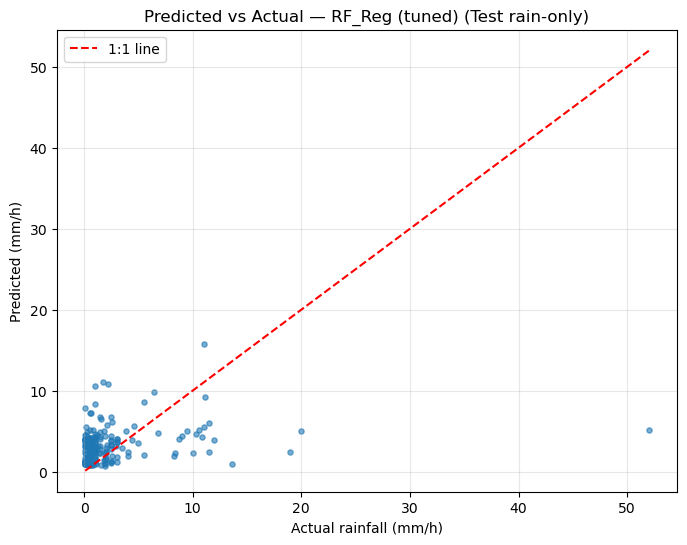

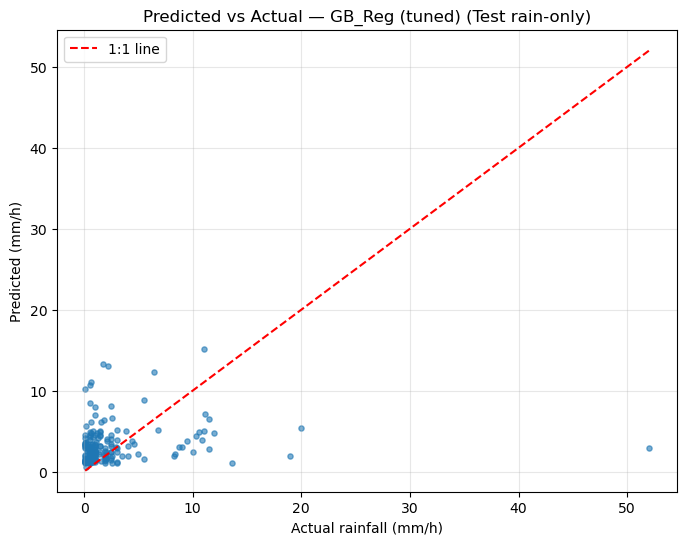

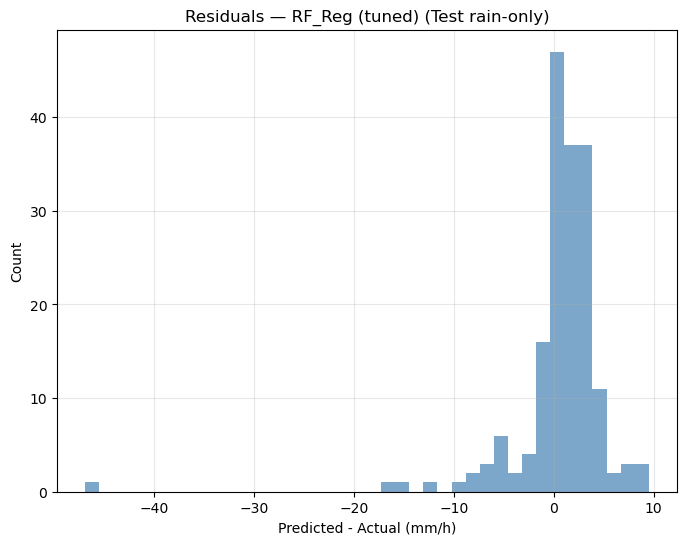

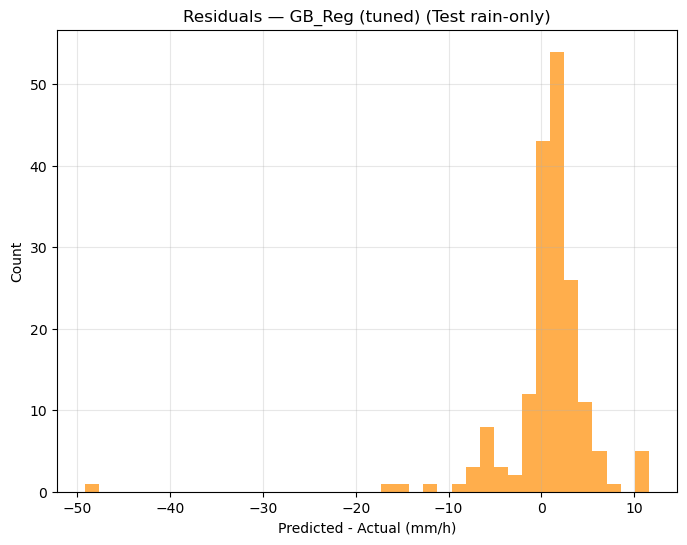

Best hyperparameters (RF_Reg):
{'reg__n_estimators': 300, 'reg__min_samples_leaf': 4, 'reg__max_features': 'sqrt', 'reg__max_depth': 8}
Best hyperparameters (GB_Reg):
{'reg__learning_rate': 0.03, 'reg__max_depth': 2, 'reg__min_samples_leaf': 4, 'reg__n_estimators': 100, 'reg__subsample': 0.8}


In [10]:
# test evaluation (rain-only)
def eval_reg(name, pipe, X, y):
    pred = pipe.predict(X)
    pred = np.clip(pred, 0, None)  # rainfall can't be negative
    mae = mean_absolute_error(y, pred)
    r   = rmse(y, pred)
    print(f"{name} — Test (rain-only) MAE={mae}, RMSE={r}")
    return pred, mae, r

pred_rf, mae_rf, rmse_rf = eval_reg('RF_Reg (tuned)', best_rf_reg, X_test_reg, y_test_reg)
pred_gb, mae_gb, rmse_gb = eval_reg('GB_Reg (tuned)', best_gb_reg, X_test_reg, y_test_reg)

# predicted vs actual scatter
for name, pred in [('RF_Reg (tuned)', pred_rf), ('GB_Reg (tuned)', pred_gb)]:
    plt.figure(figsize=(8,6))
    plt.scatter(y_test_reg, pred, s=14, alpha=0.6)
    if len(y_test_reg) > 0:
        lo, hi = float(y_test_reg.min()), float(y_test_reg.max())
        plt.plot([lo, hi], [lo, hi], 'r--', label='1:1 line')
    plt.xlabel('Actual rainfall (mm/h)')
    plt.ylabel('Predicted (mm/h)')
    plt.title(f'Predicted vs Actual — {name} (Test rain-only)')
    plt.legend(); plt.grid(alpha=0.3); plt.show()

# residual graph
better_name, better_pred = ('RF_Reg (tuned)', pred_rf) if rmse_rf <= rmse_gb else ('GB_Reg (tuned)', pred_gb)
worse_name, worse_pred  = ('GB_Reg (tuned)', pred_gb) if rmse_rf <= rmse_gb else ('RF_Reg (tuned)', pred_rf)
resid_better = better_pred - y_test_reg
resid_worse  = worse_pred  - y_test_reg
plt.figure(figsize=(8,6))
plt.hist(resid_better, bins=40, color='steelblue', alpha=0.7)
plt.title(f'Residuals — {better_name} (Test rain-only)')
plt.xlabel('Predicted - Actual (mm/h)')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8,6))
plt.hist(resid_worse, bins=40, color='darkorange', alpha=0.7)
plt.title(f'Residuals — {worse_name} (Test rain-only)')
plt.xlabel('Predicted - Actual (mm/h)')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.show()

print("Best hyperparameters (RF_Reg):")
print(rf_rs.best_params_)
print("Best hyperparameters (GB_Reg):")
print(gb_gs.best_params_)

RF_Reg is slightly better at predicting amounts when rain occurs, the error was moderate, the plots look reasonable for a noisy geophysical target

In [11]:
# select the tuned classifier by VAL F1
if f1_rf_val >= f1_logit_val:
    clf_name = 'RandomForest (tuned)'
    best_clf = best_rf
    thr_sel = thr_rf
else:
    clf_name = 'Logistic (tuned)'
    best_clf = best_logit
    thr_sel = thr_logit
print(f"Chosen classifier: {clf_name} with threshold={thr_sel}")

# select tuned regressor by VAL RMSE on rain only VAL subset
val_rain_mask = df['rf_'] > 0
X_val_reg = df.loc[val_idx & val_rain_mask, rh_cols]
y_val_reg = df.loc[val_idx & val_rain_mask, 'rf_']

# evaluate both tuned regressors on VAL rain only
pred_val_rf = np.clip(best_rf_reg.predict(X_val_reg), 0, None)
pred_val_gb = np.clip(best_gb_reg.predict(X_val_reg), 0, None)

def rmse2(y_true, y_pred):
    return float(np.sqrt(((y_true - y_pred) ** 2).mean()))

rmse_val_rf = rmse2(y_val_reg, pred_val_rf)
rmse_val_gb = rmse2(y_val_reg, pred_val_gb)

if rmse_val_rf <= rmse_val_gb:
    reg_name = 'RF_Reg (tuned)'
    best_reg = best_rf_reg
else:
    reg_name = 'GB_Reg (tuned)'
    best_reg = best_gb_reg
print(f"Chosen regressor: {reg_name} (Validation rain-only RMSE — RF={rmse_val_rf}, GB={rmse_val_gb})")

# chain on the test set
proba_test = best_clf.predict_proba(df.loc[test_idx, rh_cols])[:, 1]
preds_cls = (proba_test >= thr_sel).astype(int)
y_test_cls = df.loc[test_idx, 'rain_flag']
cm = confusion_matrix(y_test_cls, preds_cls)

tn, fp, fn, tp = cm.ravel()
print(f"Classifier CM (Test): TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# mask of predicted rain hours
pred_rain_mask = preds_cls == 1
X_test_pred_rain = df.loc[test_idx, rh_cols].loc[pred_rain_mask]
y_test_pred_rain = df.loc[test_idx, 'rf_'].loc[pred_rain_mask]

pred_amount_pred_rain = np.clip(best_reg.predict(X_test_pred_rain), 0, None)
mae_chain  = mean_absolute_error(y_test_pred_rain, pred_amount_pred_rain) if len(y_test_pred_rain) > 0 else np.nan
rmse_chain = rmse(y_test_pred_rain, pred_amount_pred_rain) if len(y_test_pred_rain) > 0 else np.nan
print(f"Chained evaluation (predicted-rain hours, TEST) — MAE={mae_chain}, RMSE={rmse_chain}, Coverage={pred_rain_mask.sum()} hours")

Chosen classifier: RandomForest (tuned) with threshold=0.44999999999999996
Chosen regressor: RF_Reg (tuned) (Validation rain-only RMSE — RF=5.89479527761847, GB=5.89498666293082)
Classifier CM (Test): TN=2035, FP=98, FN=73, TP=105
Chained evaluation (predicted-rain hours, TEST) — MAE=3.2622119667829845, RMSE=4.954249883200254, Coverage=203 hours


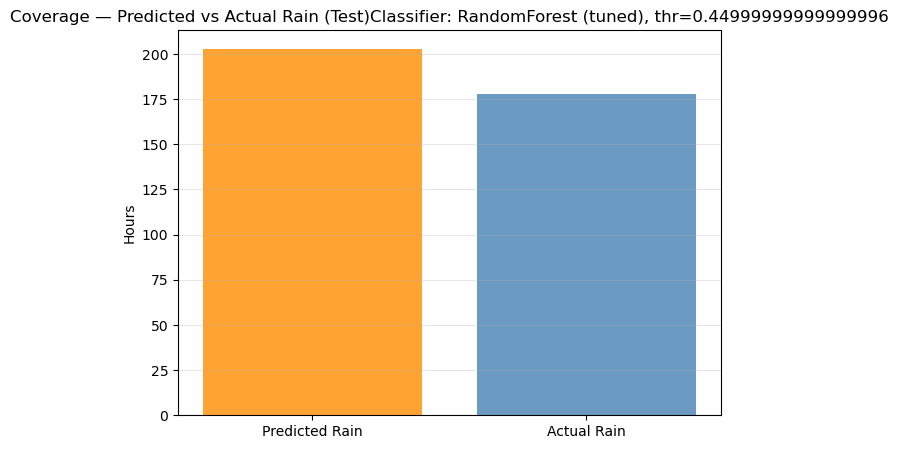

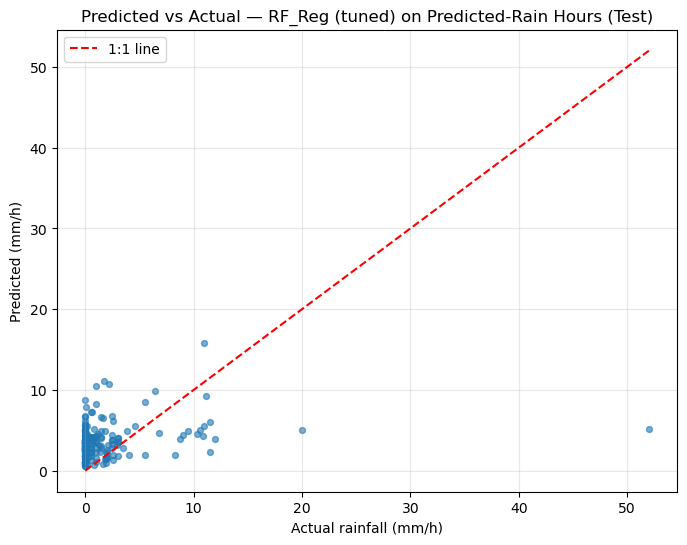

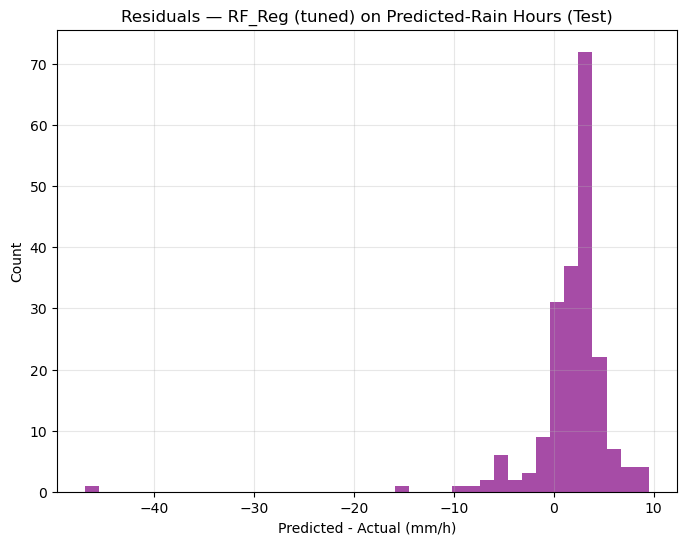

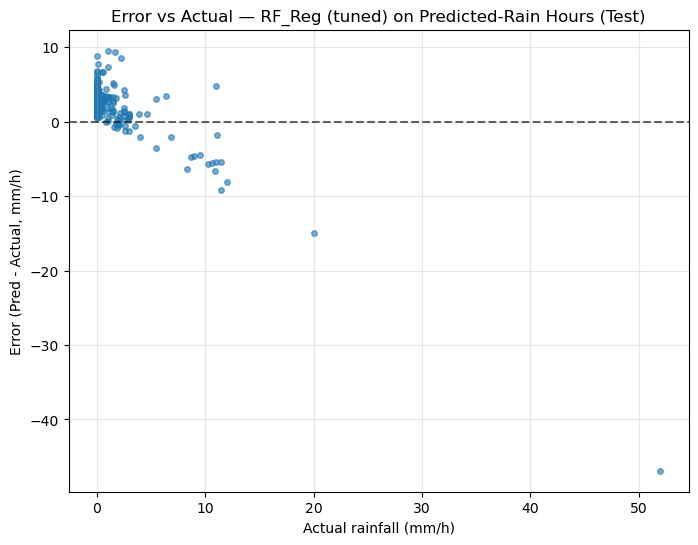

Classifier: RandomForest (tuned)threshold: 0.44999999999999996
Regressor: RF_Reg (tuned)
Test: Predicted-Rain hours = 203 (Actual rain hours = 178)
Amount metrics on predicted-rain hours: MAE=3.2622119667829845, RMSE=4.954249883200254


In [12]:
actual_rain_count = int((df.loc[test_idx, 'rf_'] > 0).sum())
pred_rain_count   = int(pred_rain_mask.sum())
plt.figure(figsize=(7,5))
plt.bar(['Predicted Rain', 'Actual Rain'], [pred_rain_count, actual_rain_count], color=['darkorange', 'steelblue'], alpha=0.8)
plt.title(f'Coverage — Predicted vs Actual Rain (Test)Classifier: {clf_name}, thr={thr_sel}')
plt.ylabel('Hours')
plt.grid(axis='y', alpha=0.3)
plt.show()

# predicted vs actual amount on predicted-rain hours
plt.figure(figsize=(8,6))
plt.scatter(y_test_pred_rain, pred_amount_pred_rain, s=18, alpha=0.6)
if len(y_test_pred_rain) > 0:
    lo, hi = float(y_test_pred_rain.min()), float(y_test_pred_rain.max())
    plt.plot([lo, hi], [lo, hi], 'r--', label='1:1 line')
plt.xlabel('Actual rainfall (mm/h)')
plt.ylabel('Predicted (mm/h)')
plt.title(f'Predicted vs Actual — {reg_name} on Predicted-Rain Hours (Test)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

if len(y_test_pred_rain) > 0:
    resid = pred_amount_pred_rain - y_test_pred_rain
    plt.figure(figsize=(8,6))
    plt.hist(resid, bins=40, color='purple', alpha=0.7)
    plt.title(f'Residuals — {reg_name} on Predicted-Rain Hours (Test)')
    plt.xlabel('Predicted - Actual (mm/h)')
    plt.ylabel('Count')
    plt.grid(alpha=0.3)
    plt.show()

if len(y_test_pred_rain) > 0:
    err = pred_amount_pred_rain - y_test_pred_rain
    plt.figure(figsize=(8,6))
    plt.scatter(y_test_pred_rain, err, s=16, alpha=0.6)
    plt.axhline(0, color='k', linestyle='--', alpha=0.6)
    plt.xlabel('Actual rainfall (mm/h)'); plt.ylabel('Error (Pred - Actual, mm/h)')
    plt.title(f'Error vs Actual — {reg_name} on Predicted-Rain Hours (Test)')
    plt.grid(alpha=0.3)
    plt.show()

print(f"Classifier: {clf_name}threshold: {thr_sel}")
print(f"Regressor: {reg_name}")
print(f"Test: Predicted-Rain hours = {pred_rain_count} (Actual rain hours = {actual_rain_count})")
print(f"Amount metrics on predicted-rain hours: MAE={mae_chain}, RMSE={rmse_chain}")

The classifier over predicts rain (203 predicted vs 178 actual), the amount of errors are comparable to those in the pure rain only evaluation, which is good, the regressor behaves similarly on the subset chosen by the classifier

My model predicts rainfall occurrence better than rainfall amount, since using only RH by level can be limiting

There are many other features like temperature and wind shear that would affect rainfall amount

Maybe I can split the model into light vs heavy rain (for example threshold at 5 mm/h) and train separate regressors, this may improve the prediction? I guess